# Scénarios numériques du mémoire — chapitre 5

Le noyau numérique, les métriques et les références homogènes sont importés depuis `mfg_liquidation`. Les paramètres communs sont :

$$
T=1,\qquad N=2000,\qquad \mathcal V=2\,000\,000,\qquad \eta=0.1,\qquad \sigma=0.3,\qquad \alpha=8\times10^{-8},
$$

avec $\lambda=0.35$ et $\varepsilon=10^{-8}$ pour le point fixe.

Les figures conservent la même convention visuelle que celles insérées dans le mémoire : une couleur par sous-population, ligne pleine pour l'interaction hétérogène, ligne de tirets de même couleur pour la référence homogène et ligne tiret-point pour le flux agrégé $\mu$.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start=None):
    """Locate the repository root from a notebook running inside the project."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src" / "mfg_liquidation").is_dir():
            return candidate
    raise RuntimeError(
        "Repository root not found. Start Jupyter/PyCharm from inside the cloned project."
    )


ROOT = find_project_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mfg_liquidation.experiments import run_thesis_scenario, save_scenario_table
from mfg_liquidation.parameters import SCENARIOS_BY_KEY
from mfg_liquidation.plotting import plot_inventory_trajectories, plot_speed_trajectories

FIGURE_DIR = ROOT / "results" / "figures"
TABLE_DIR = ROOT / "results" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {ROOT}")
print("Environnement du projet initialisé.")


Projet : C:\Users\casol\Desktop\perso\liquidation_MFG
Environnement du projet initialisé.


In [2]:
def run_and_display(scenario_key):
    scenario = SCENARIOS_BY_KEY[scenario_key]
    result = run_thesis_scenario(scenario)

    references = result["references"]
    reference_qbar = None if references is None else references["qbar"]
    reference_vbar = None if references is None else references["vbar"]

    inventory_path = FIGURE_DIR / f"figure_{int(scenario.figure_number):02d}_{scenario.key}_inventaire.svg"
    speed_path = FIGURE_DIR / f"figure_{int(scenario.figure_number):02d}_{scenario.key}_vitesse.svg"

    fig_inventory, _ = plot_inventory_trajectories(
        result["t_grid"],
        result["qbar"],
        reference_qbar=reference_qbar,
        filename=inventory_path,
    )
    plt.show()
    plt.close(fig_inventory)

    fig_speed, _ = plot_speed_trajectories(
        result["t_grid"],
        result["vbar"],
        scenario.rho,
        reference_vbar=reference_vbar,
        filename=speed_path,
    )
    plt.show()
    plt.close(fig_speed)

    display(result["table"].style.set_properties(**{"text-align": "center"}))
    csv_path, tsv_path = save_scenario_table(result, TABLE_DIR)

    print(
        f"Section {scenario.section} — Figure {scenario.figure_number} / Tableau {scenario.table_number}\n"
        f"Point fixe : {result['info'].n_iter} itérations, erreur finale = {result['info'].error:.3e}\n"
    )
    return result

## 5.3 — Aversion au risque

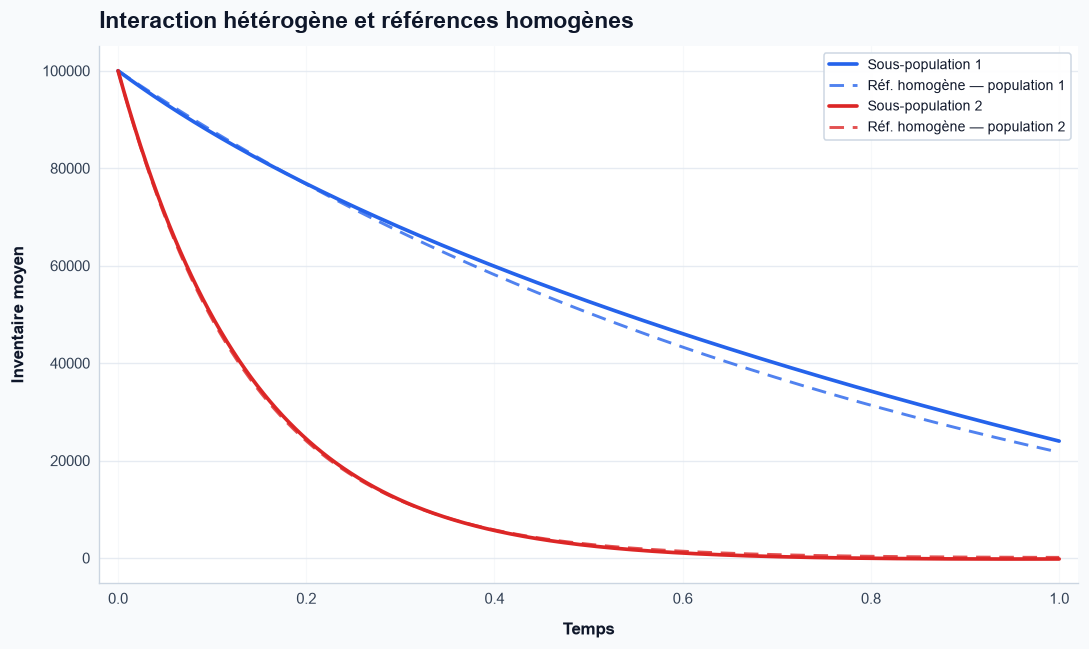

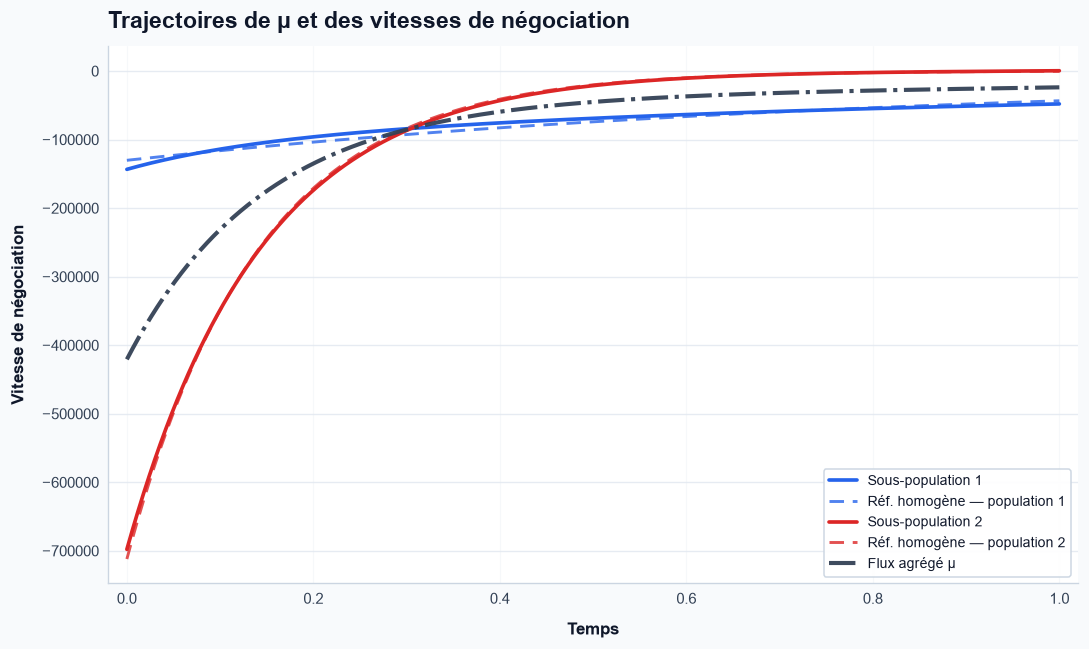

,SOUS-POPULATION 1,SOUS-POPULATION 2,POPULATION 1 HOMOGÈNE,POPULATION 2 HOMOGÈNE
,,,,
q̄_T,23 991,-206,21 695,129
VOLUME,75 985,100 048,78 283,99 693
EXPOSITION AU RISQUE,"0,3526","0,0711","0,3391","0,0701"
COÛT TEMPORAIRE,"0,0042","0,0175","0,0043","0,0178"
INDICE D’IMPACT PERMANENT,"-0,0047","-0,0026","-0,0031","-0,0040"


Section 5.3 — Figure 3 / Tableau 2
Point fixe : 76 itérations, erreur finale = 7.800e-09



In [3]:
risk_aversion_result = run_and_display("risk_aversion")

## 5.4 — Pénalisation de l’inventaire terminal

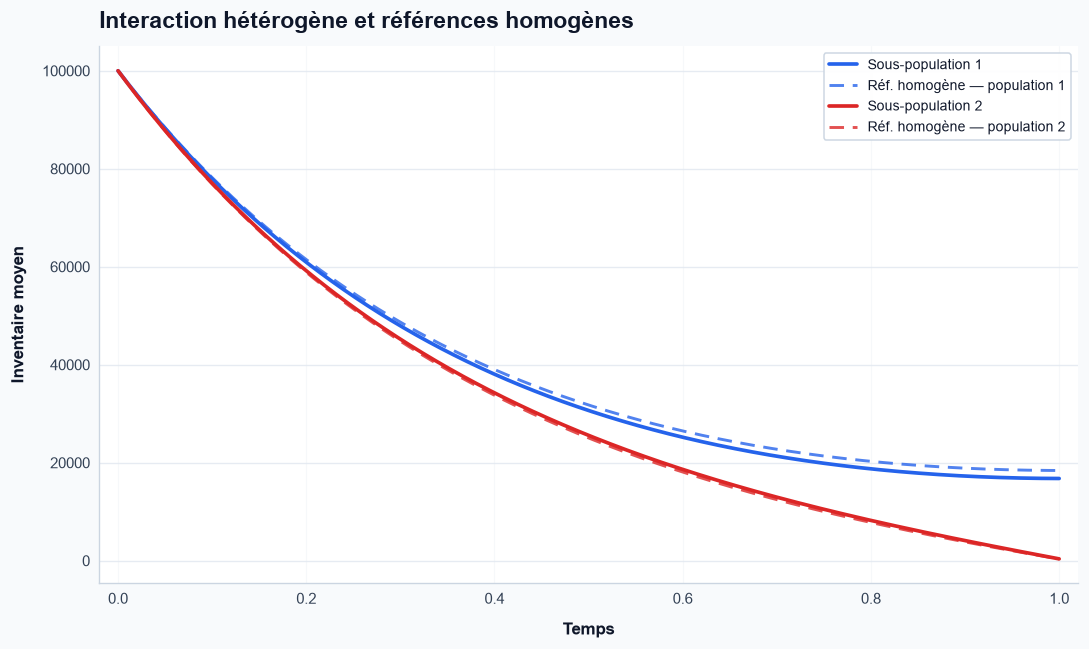

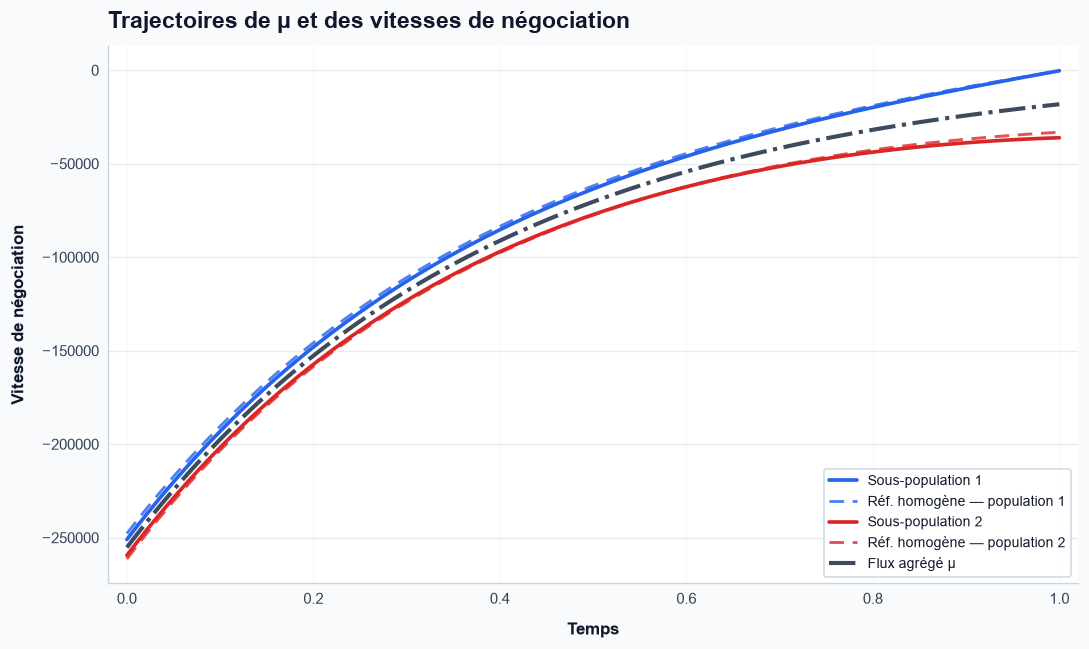

,SOUS-POPULATION 1,SOUS-POPULATION 2,POPULATION 1 HOMOGÈNE,POPULATION 2 HOMOGÈNE
,,,,
q̄_T,16 772,362,18 408,332
VOLUME,83 165,99 583,81 531,99 611
EXPOSITION AU RISQUE,"0,2093","0,1848","0,2154","0,1827"
COÛT TEMPORAIRE,"0,0070","0,0069","0,0069","0,0070"
INDICE D’IMPACT PERMANENT,"-0,0034","-0,0038","-0,0033","-0,0040"


Section 5.4 — Figure 5 / Tableau 3
Point fixe : 76 itérations, erreur finale = 8.731e-09



In [4]:
terminal_penalty_result = run_and_display("terminal_penalty")

## 5.5 — Inventaire initial

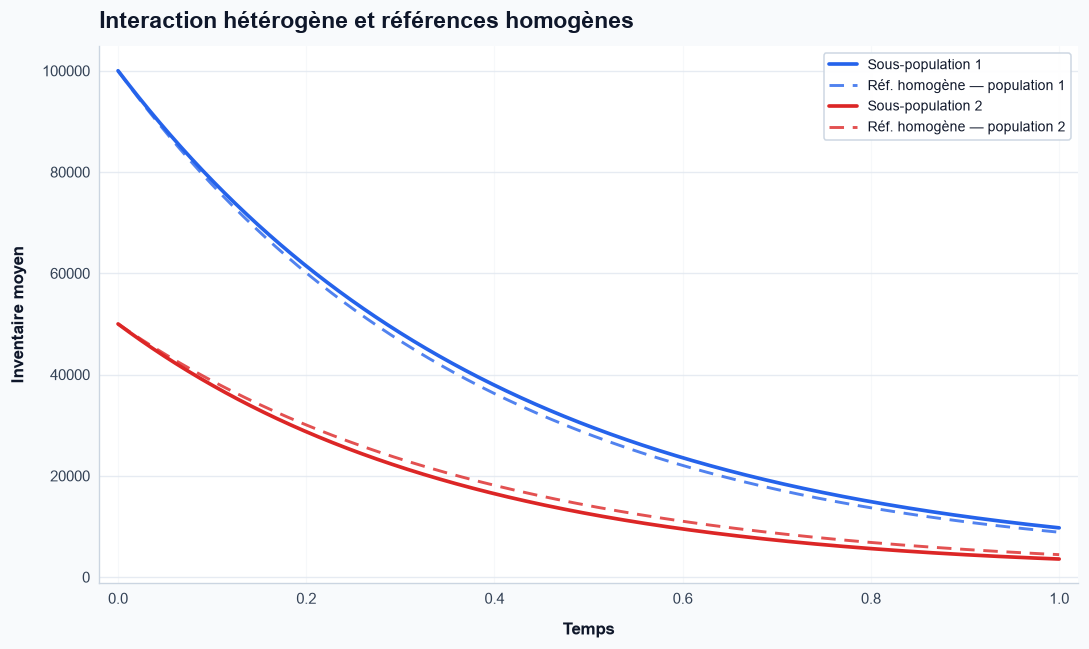

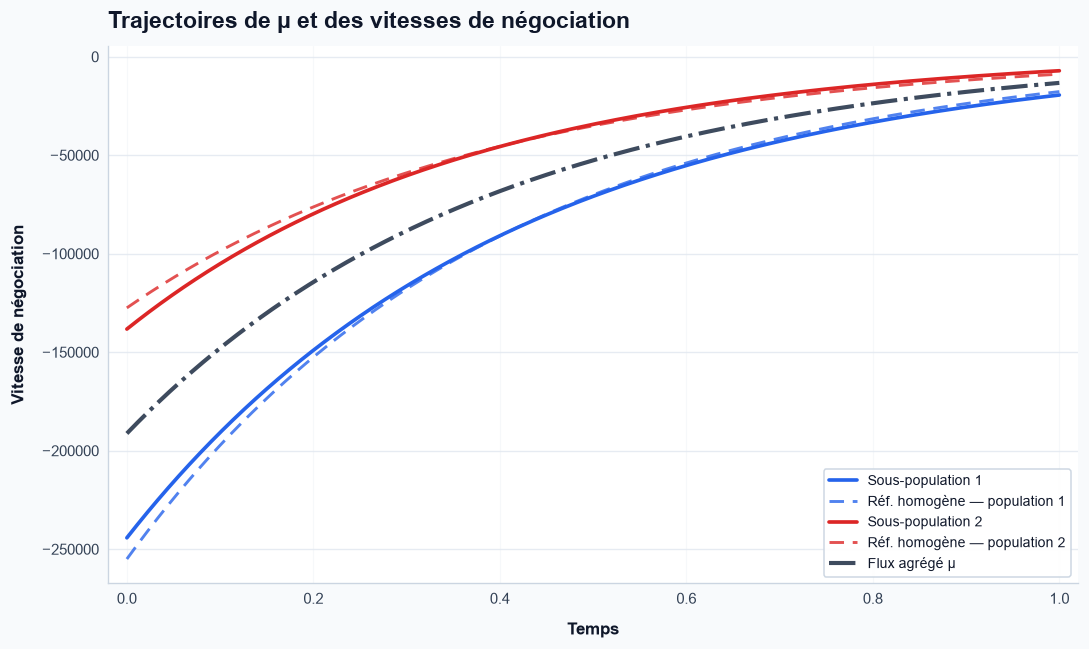

,SOUS-POPULATION 1,SOUS-POPULATION 2,POPULATION 1 HOMOGÈNE,POPULATION 2 HOMOGÈNE
,,,,
q̄_T,9 725,3 564,8 859,4 429
VOLUME,90 219,46 403,91 082,45 541
EXPOSITION AU RISQUE,"0,2048","0,1798","0,1961","0,1961"
COÛT TEMPORAIRE,"0,0066","0,0037","0,0069","0,0034"
INDICE D’IMPACT PERMANENT,"-0,0028","-0,0026","-0,0036","-0,0018"


Section 5.5 — Figure 7 / Tableau 4
Point fixe : 76 itérations, erreur finale = 7.218e-09



In [5]:
initial_inventory_result = run_and_display("initial_inventory")

## 5.6 — Taille des sous-populations et opportunisme : masses 0,5 / 0,5

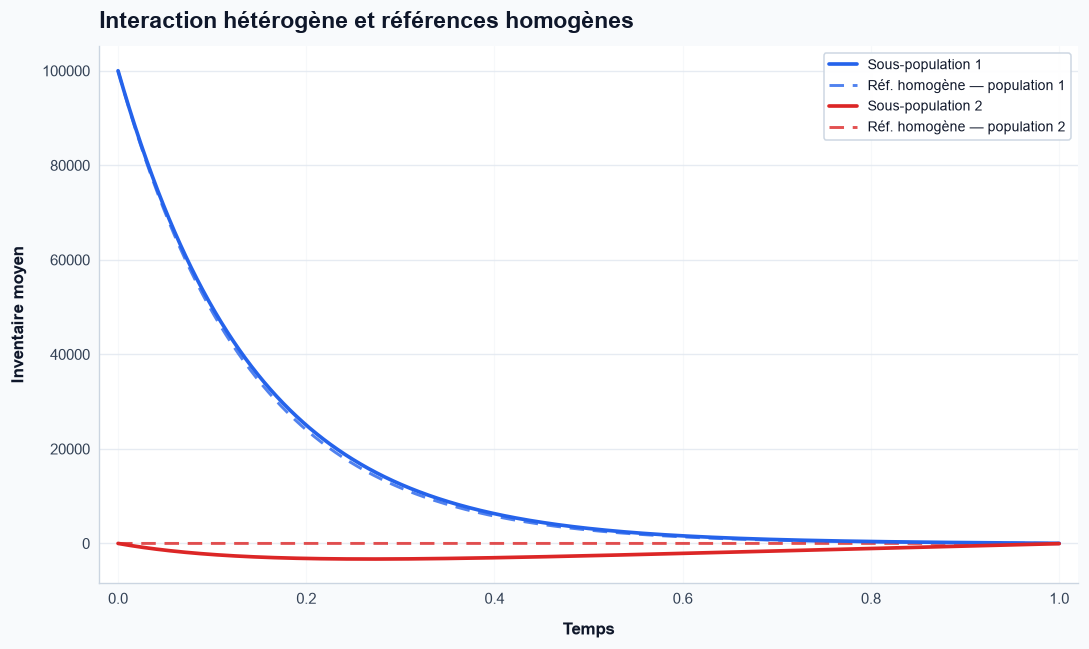

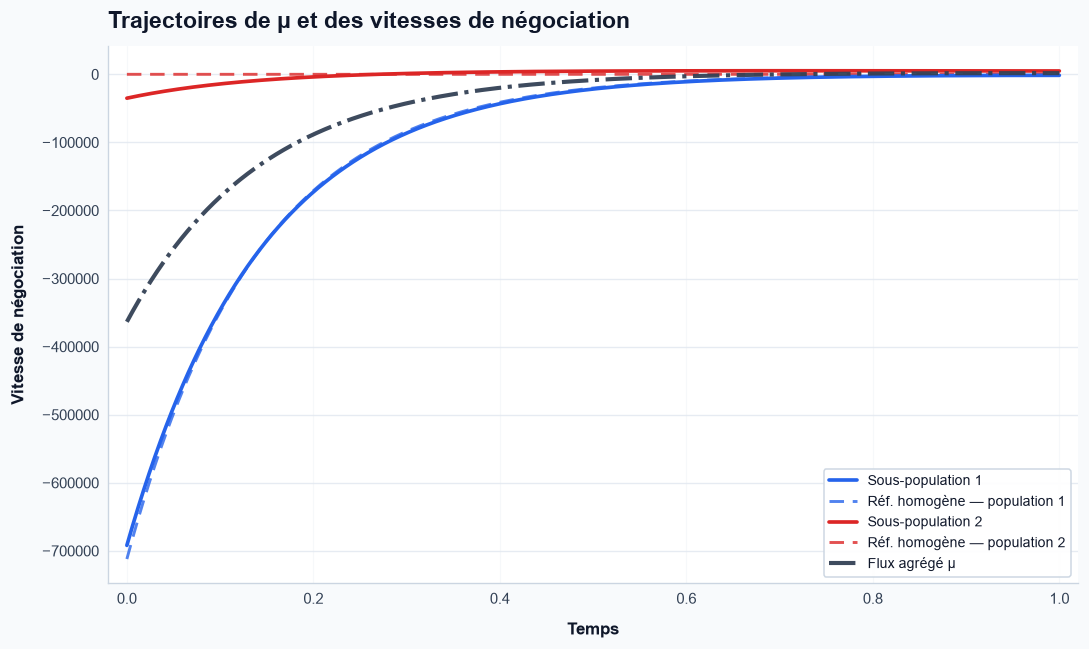

,SOUS-POPULATION 1,SOUS-POPULATION 2,POPULATION 1 HOMOGÈNE,POPULATION 2 HOMOGÈNE
,,,,
q̄_T,15,-49,10,0
VOLUME,99 812,6 549,99 812,0
EXPOSITION AU RISQUE,"0,0722",N/A,"0,0701",N/A
COÛT TEMPORAIRE,"0,0173","0,0006","0,0178",N/A
INDICE D’IMPACT PERMANENT,"-0,0021","0,0012","-0,0040",N/A


Section 5.6 — Figure 9 / Tableau 5
Point fixe : 75 itérations, erreur finale = 6.636e-09



In [6]:
opportunism_equal_masses_result = run_and_display("opportunism_equal_masses")

## 5.6 — Taille des sous-populations et opportunisme : masses 0,95 / 0,05

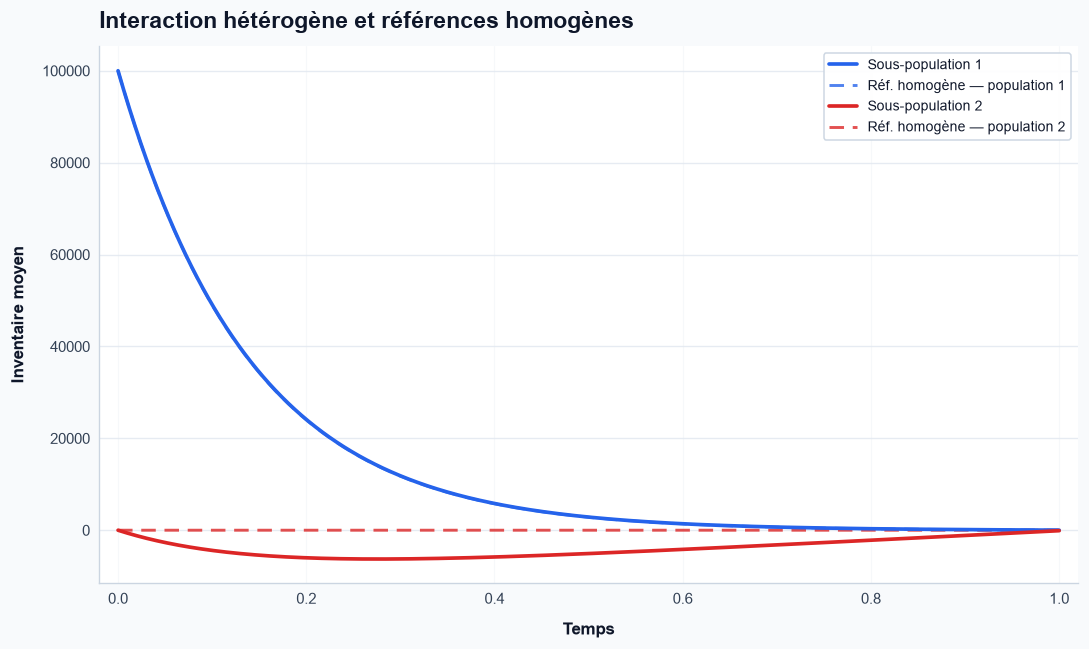

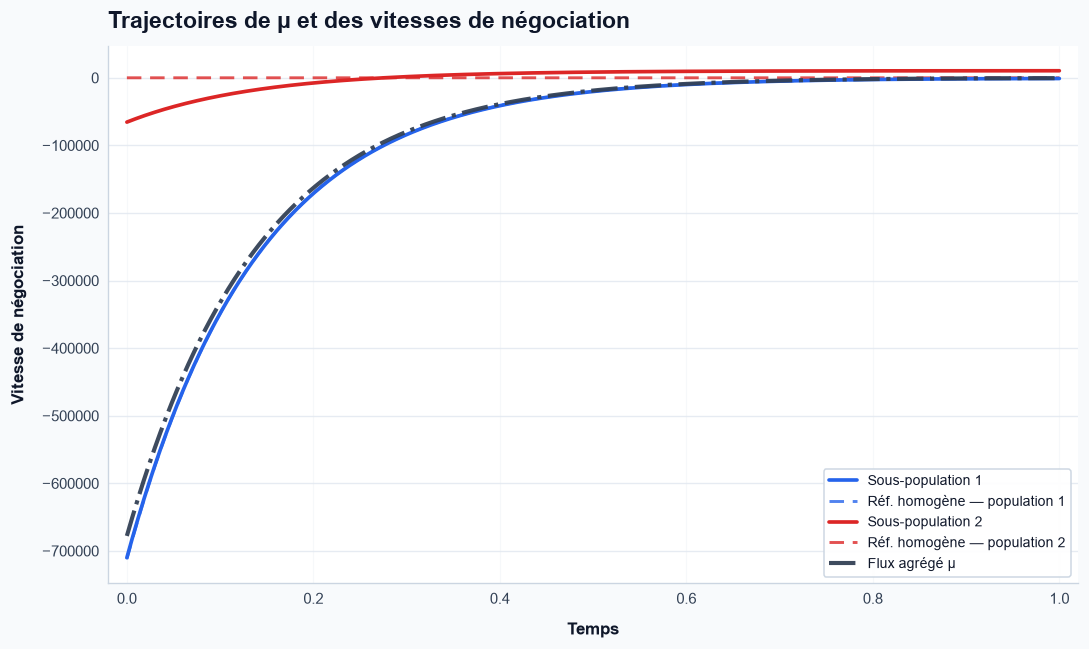

,SOUS-POPULATION 1,SOUS-POPULATION 2,POPULATION 1 HOMOGÈNE,POPULATION 2 HOMOGÈNE
,,,,
q̄_T,11,-104,10,0
VOLUME,99 812,12 426,99 812,0
EXPOSITION AU RISQUE,"0,0703",N/A,"0,0701",N/A
COÛT TEMPORAIRE,"0,0178","0,0012","0,0178",N/A
INDICE D’IMPACT PERMANENT,"-0,0038","0,0023","-0,0040",N/A


Section 5.6 — Figure 10 / Tableau 6
Point fixe : 78 itérations, erreur finale = 6.869e-09



In [7]:
opportunism_95_5_result = run_and_display("opportunism_95_5")

## 5.7 — Quatre sous-populations : combinaisons de γ et A

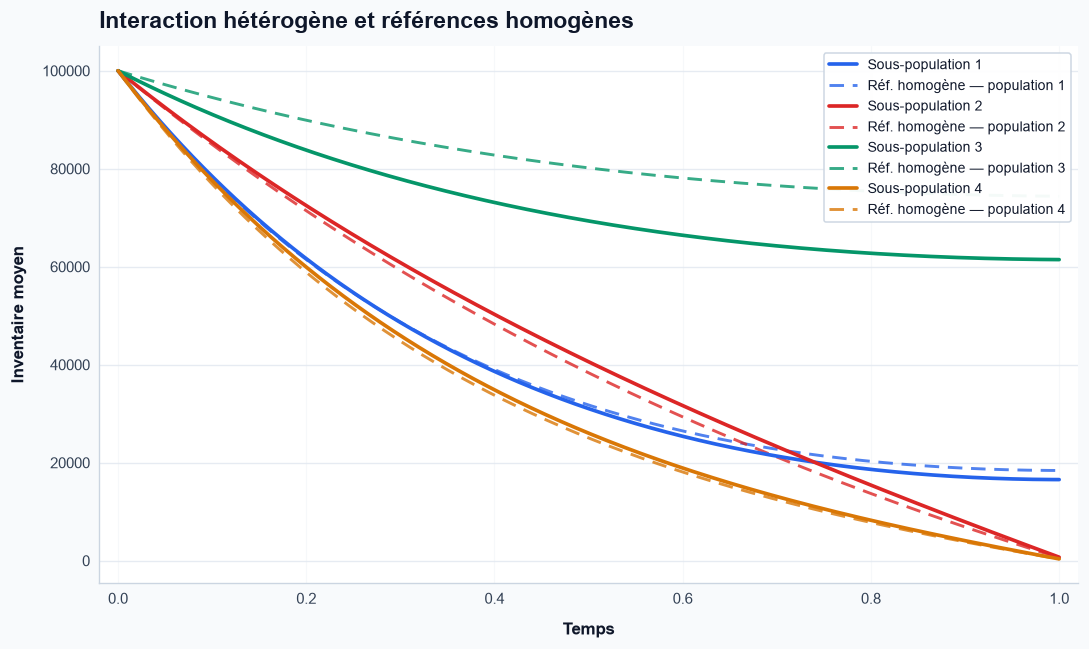

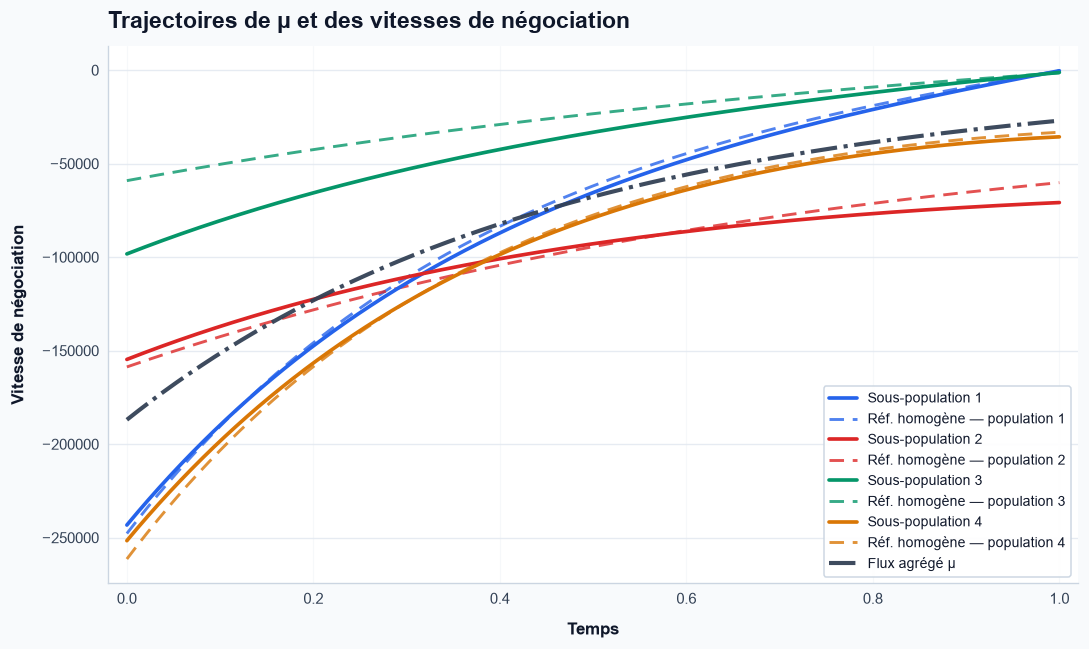

,SOUS-POPULATION 1,SOUS-POPULATION 2,SOUS-POPULATION 3,SOUS-POPULATION 4,POPULATION 1 HOMOGÈNE,POPULATION 2 HOMOGÈNE,POPULATION 3 HOMOGÈNE,POPULATION 4 HOMOGÈNE
,,,,,,,,
q̄_T,16 547,708,61 450,357,18 408,602,74 381,332
VOLUME,83 392,99 271,38 525,99 589,81 531,99 374,25 605,99 611
EXPOSITION AU RISQUE,"0,2124","0,2702","0,5456","0,1881","0,2154","0,2591","0,6859","0,1827"
COÛT TEMPORAIRE,"0,0068","0,0052","0,0029","0,0068","0,0069","0,0054","0,0018","0,0070"
INDICE D’IMPACT PERMANENT,"-0,0028","-0,0038","-0,0029","-0,0031","-0,0033","-0,0040","-0,0010","-0,0040"


Section 5.7 — Figure 11 / Tableau 7
Point fixe : 78 itérations, erreur finale = 7.218e-09



In [8]:
four_populations_gamma_A_result = run_and_display("four_populations_gamma_A")

## Fichiers produits

Chaque scénario sauvegarde deux fichiers SVG vectoriels correspondant aux deux graphiques placés côte à côte dans le mémoire, ainsi qu'un CSV.